# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('album_sales.csv')

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

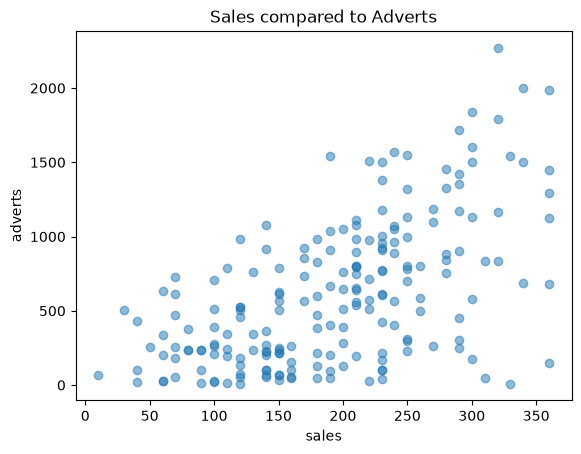

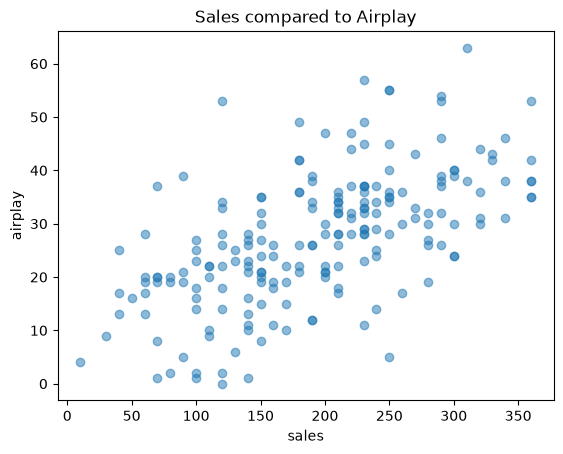

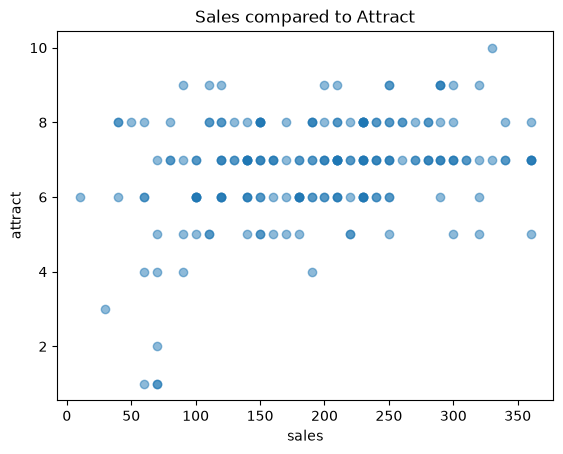

In [4]:
def scatter(x_col, y_col):    
    plt.scatter(x=df[x_col], y=df[y_col], alpha=0.5)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

plt.title('Sales compared to Adverts')
scatter('sales', 'adverts')

plt.title('Sales compared to Airplay')
scatter('sales', 'airplay')

plt.title('Sales compared to Attract')
scatter('sales', 'attract')

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

### Scatterplot 1
 Looks to be almost an exponential relationship with no outliers to one side

### Scatterplot 2 
looks pretty positive and linear

### Scatterplot 3 
also looks pretty linear and positive

<br>
<br>

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [8]:
stat_x = sm.add_constant(df['adverts'])
stat_y = df['sales']

model = sm.OLS(stat_y, stat_x).fit()
predictions = model.predict(stat_x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        18:39:53   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-statistic is 99.59 and the P-value of 2.94 × 10^-19. Since the P-value is much smaller than 0.05 the regression model is statistically significant. This suggests that there is a significant relationship between advertising and sales, so the model has statistical bearing rather than being due to random chance.

<br>
<br>

### 3. Model Coefficients (10 points)

- Make note of the **intercept** (const coef = 134.1399) value and **coefficient** (adverts = 0.0961) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [10]:
z = 135000     # money spent
x = z / 1000   # z divided by 1000 to show value is in value
#   intercept    coef     moneyspent
y = 134.1399 + (0.0961   *   x)

print()
print(f'How many records if {z} $ is spent: {y}')
print()
print()


How many records if 135000 $ is spent: 147.1134




### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [14]:
stat_x = sm.add_constant(df[['adverts', 'airplay', 'attract']])
stat_y = df['sales']


model = sm.OLS(stat_y, stat_x).fit()
predictions = model.predict(stat_x)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        18:47:37   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

The second model would be better because it explains more of the variation in sales using multiple predictors. Model 2 has an R^2 value of 0.665, while Model 1 has an R^2 value of 0.335. This means Model 2 explains 66.5% of the variation in sales, compared to 33.5% for Model 1.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name